## Homework 1 (50pts)

- 1. Replicate the experiment in the bottom Figure (Steps vs % Optimal Action) in Figure 2.2 of Sutton & Barto by 2000 runs of epsilon, each with 1000 steps, and plot the average Steps vs the average % Optimal Action. The mean and standard deviation of the reward of each of the 10 arms is based on the description in the caption of Figure 2.1. Namely, each arm a has action value q(a) \in N(0,std) with std = 1. It's OK if you don't get exactly the same plot, as long as the trend looks similar
- 2. Now increase the standard deviation std of the reward of each arm to 5 from 1. Rerun the experiments, and plot again. What do you observe? Discuss how percentage of optimal action change from the previous experiment to the current at 1000-th steps and explain intuitively why this happens.
 
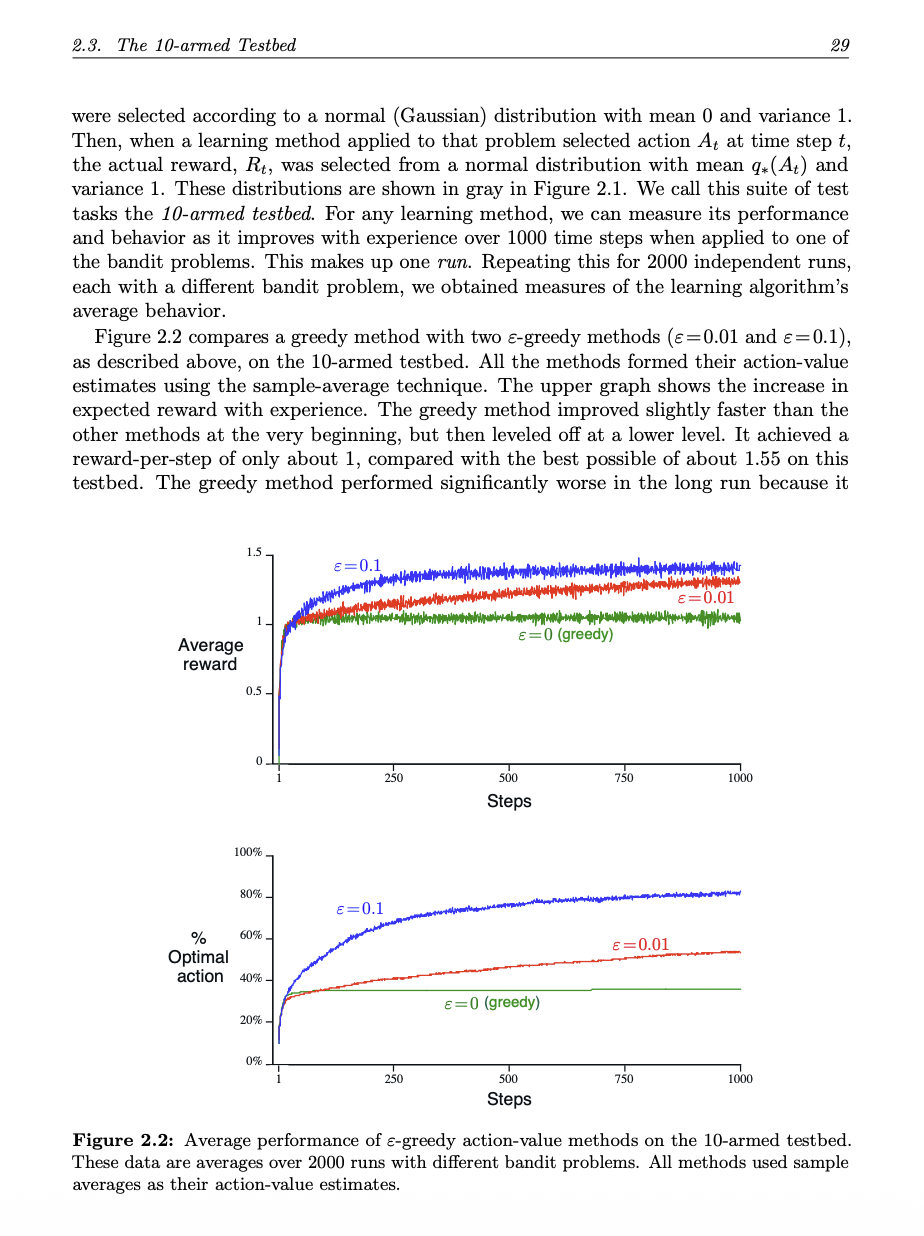

# 1.

whole procedure: For each step, I play one bandit and record the reward for this certain bandit. Since this procedure will repeat nRun times, I will make a list to run NRun synchronized.

Setup (once per run $i = 1, \dots, 2000$)

$$q^*_i(a) \sim \mathcal{N}(0, \sigma_q^2), \qquad a = 1, \dots, 10$$

q_star = rng.normal(0.0, std_q, size=(N_RUNS, N_ARMS))
$$a^*_i = \arg\max_a q^*_i(a)$$

Explain what's actions array:


$$\texttt{actions}[i] = \begin{cases} \texttt{random\_actions}[i] & \text{if } \texttt{explore}[i] = \text{True} \\ \texttt{greedy\_actions}[i] & \text{if } \texttt{explore}[i] = \text{False} \end{cases}$$



Equivalently, action itself is determined by a Bernoulli distribution.

$$A_{i,t} = \begin{cases} \text{Uniform}\{1, \dots, 10\} & X_{i,t} = 1 \\ \arg\max_a Q_i(a) \;\text{(ties random)} & X_{i,t} = 0 \end{cases}$$


Update only the chosen arm $a = A_{i,t}$:
$$N_i(a) \leftarrow N_i(a) + 1, \qquad Q_i(a) \leftarrow Q_i(a) + \frac{R_{i,t} - Q_i(a)}{N_i(a)}$$

=== % optimal action at step 1000 ===
   epsilon |    std=1 |    std=5|  change
       0.0 |    36.00 |    26.40 |    -9.60
      0.01 |    61.05 |    67.55 |    +6.50
       0.1 |    79.20 |    88.25 |    +9.05


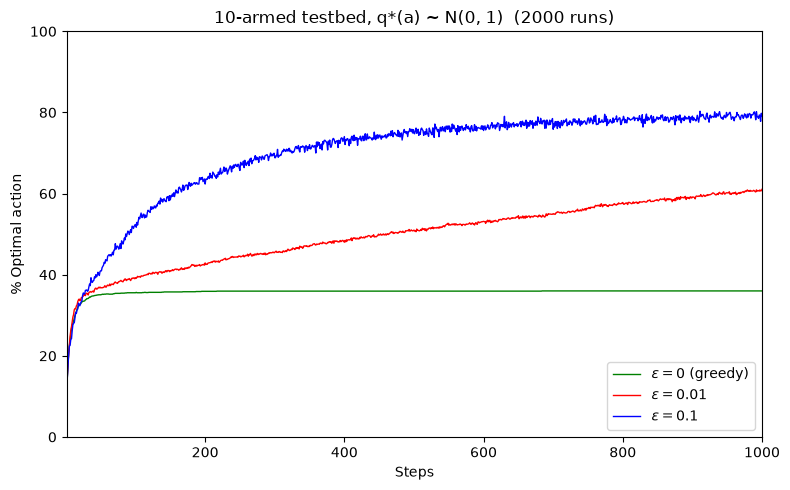

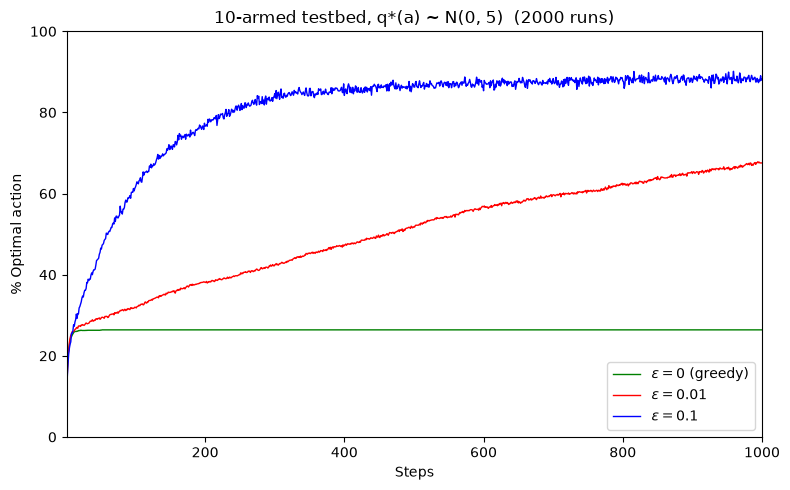

In [37]:
import numpy as np
import matplotlib.pyplot as plt

N_ARMS = 10
N_RUNS = 2000
N_STEPS = 1000
EPSILONS = [0.0, 0.01, 0.1]
COLORS = {0.0: "green", 0.01: "red", 0.1: "blue"}
LABELS = {0.0: r"$\varepsilon=0$ (greedy)", 0.01: r"$\varepsilon=0.01$", 0.1: r"$\varepsilon=0.1$"}


def run_experiment(std_q, seed):
    """Run all three epsilon-greedy agents for N_RUNS x N_STEPS and return
    a dict: epsilon -> array of shape (N_STEPS,) giving % optimal action at each step."""
    rng = np.random.default_rng(seed)
    results = {}

# env setting
    for eps in EPSILONS:
        # True action values for every run, shape (N_RUNS, N_ARMS)
        q_star = rng.normal(0.0, std_q, size=(N_RUNS, N_ARMS))
        optimal_action = np.argmax(q_star, axis=1)  # shape (N_RUNS,)

        Q = np.zeros((N_RUNS, N_ARMS))
        N = np.zeros((N_RUNS, N_ARMS))
        pct_optimal = np.empty(N_STEPS)

        run_idx = np.arange(N_RUNS)

        for t in range(N_STEPS):
            explore = rng.random(N_RUNS) < eps # boolean aray,Bernoulli distribution
            Q_tiebreak = Q + rng.random(Q.shape) * 1e-9# + U(0,1e-9) each step
            greedy_actions = np.argmax(Q_tiebreak, axis=1)#Best by row, for each run
            random_actions = rng.integers(0, N_ARMS, size=N_RUNS)
            actions = np.where(explore, random_actions, greedy_actions)#Which one did you exactly play?
            

            # sample reward ~ N(q*(a), 1)
            rewards = rng.normal(q_star[run_idx, actions], 1.0)

            # incremental sample-average update
            N[run_idx, actions] += 1
            Q[run_idx, actions] += (rewards - Q[run_idx, actions]) / N[run_idx, actions]

            pct_optimal[t] = np.mean(actions == optimal_action)

        results[eps] = pct_optimal * 100.0# Expand to the percentage

    return results


def plot_results(results, title):
    plt.figure(figsize=(8, 5))
    steps = np.arange(1, N_STEPS + 1)
    for eps in EPSILONS:
        plt.plot(steps, results[eps], color=COLORS[eps], label=LABELS[eps], linewidth=1)
    plt.xlabel("Steps")
    plt.ylabel("% Optimal action")
    plt.ylim(0, 100)
    plt.xlim(1, N_STEPS)
    plt.title(title)
    plt.legend(loc="lower right")
    plt.tight_layout()
  


if __name__ == "__main__":
    results_std1 = run_experiment(std_q=1.0, seed=1)
    plot_results(
        results_std1,
        "10-armed testbed, q*(a) ~ N(0, 1)  (2000 runs)"
    )

    results_std5 = run_experiment(std_q=5.0, seed=2)
    plot_results(
        results_std5,
        "10-armed testbed, q*(a) ~ N(0, 5)  (2000 runs)"
    )

    print("=== % optimal action at step 1000 ===")
    print(f"{'epsilon':>10} | {'std=1':>8} | {'std=5':>8}|{'change':>8}")
    for eps in EPSILONS:
        p1 = results_std1[eps][-1]      # [-1] = last element = step 1000
        p5 = results_std5[eps][-1]
        print(f"{eps:>10} | {p1:>8.2f} | {p5:>8.2f} | {p5 - p1:>+8.2f}")

What happens when the variance becomes larger: It improves both ε-greedy methods but makes the greedy method worse.For if we increase the variance, then the gap between each value is increasing.Then if you use greedy, it'll be much easier to find the true value.However, since when epsilon is not zero, we are actually increasing the exploration. So, the sparse reverse space will make this algorithm hard to converge.

## Homework 2 (20 pts)

If you are working on a MAB problem with 10 arms, their expected rewards are $[1,2,3,4,5,6,7,8,9,10]$. You use $\epsilon$-greedy algorithm to decide on the arm. 
- 1. What's expected reward at time $t$ as $t\rightarrow \infty$? (as a function of $\epsilon$)
- 2. What's expected regret at time $t$ as $t\rightarrow \infty$? (as a function of $\epsilon$)


1.
$$
\mathbb{E}[R_t] = \sum_{i=1}^{10} r_i \, P(A_t = i)
= \frac{55\varepsilon}{10} + (1-\varepsilon)\sum_{i=1}^{10} r_i \, P(A_t = i \mid \text{greedy})
$$

By observation, the greedy step chooses arm $i$ exactly when arm $i$ has been tried at least once and arms $i+1, \dots, 10$ have never been tried. Treating each of the past $t$ choices as a uniform draw over the 10 arms,

$$
P(A_t = i \mid \text{greedy}) = \left(\frac{i}{10}\right)^t - \left(\frac{i-1}{10}\right)^t
$$

since $\left(\frac{i}{10}\right)^t$ is the probability that every draw lands in $\{1, \dots, i\}$, and subtracting $\left(\frac{i-1}{10}\right)^t$ removes the case where arm $i$ itself was never drawn.

With $r_i = i$, the greedy part expands as

$$
\begin{aligned}
\sum_{i=1}^{10} i \left[\left(\tfrac{i}{10}\right)^t - \left(\tfrac{i-1}{10}\right)^t\right]
=\;&10 \times \left[1 - \left(\tfrac{9}{10}\right)^t\right] \\
+\;&9 \times \left[\left(\tfrac{9}{10}\right)^t - \left(\tfrac{8}{10}\right)^t\right] \\
+\;&8 \times \left[\left(\tfrac{8}{10}\right)^t - \left(\tfrac{7}{10}\right)^t\right] \\
+\;&\cdots \\
+\;&1 \times \left(\tfrac{1}{10}\right)^t
\end{aligned}
$$

As $t \to \infty$, $\left(\frac{i}{10}\right)^t \to 0$ for every $i \le 9$, so every term vanishes except $10 \times 1$:

$$
\lim_{t \to \infty} \sum_{i=1}^{10} i \, P(A_t = i \mid \text{greedy}) = 10,
$$

$$
\lim_{t \to \infty} \mathbb{E}[R_t] = \frac{55}{10}\varepsilon + (1-\varepsilon) \times 10 = 10 - 4.5\,\varepsilon.
$$

2.
By the result of 1:

$$\mathbb{E}[\text{Regret}_t] = \mathbb{E}[10 - R_t] = 10 - \mathbb{E}[R_t] = 10 - (10 - 4.5\,\varepsilon) = 4.5.\,\varepsilon$$


## Homework 3 (10 pts)

Which of the following best describes UCB’s behavior?

- A. UCB always picks the arm with the highest empirical mean, ignoring uncertainty.
- B. UCB picks the arm with the highest upper confidence bound, exploring arms with higher uncertainty.
- C. UCB randomly selects arms, with probabilities proportional to their empirical means.
- D. UCB requires a prior distribution over rewards to estimate expected values.

Answer:B

## Homework 4 (10 pts)

Which statement correctly describes how Thompson Sampling explores?

- A. It always selects the arm with the highest empirical mean.
- B. It selects an arm randomly, ignoring past observations.
- C. It samples from the posterior distribution of each arm’s mean and picks the arm with the largest sample.
- D. It computes the upper confidence bound and picks the arm with the highest bound.

Answer:c

## Homework 5 (10 pts)

Suppose you are choosing between UCB and Thompson Sampling on a 3-armed bandit with unknown rewards. Which of the following statements is true?

- A. Both algorithms explore more when an arm’s reward is uncertain.
- B. Only UCB explores; Thompson Sampling is greedy.
- C. UCB requires a prior distribution, while Thompson Sampling does not.
- D. Neither algorithm adapts exploration based on past observations.

Answer:A